In [101]:
import talus_python.morse as morse
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import umap

In [2]:
from transformers import GPT2Tokenizer, GPT2Model
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2', attn_implementation="eager")



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [58]:
text = "It was the year when they finally immanentized the Eschaton. On April 1, the world's great powers came closer to nuclear war than ever before, all because of an obscure island named Fernando Poo."
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input, output_attentions=True)

In [75]:
output = model(**encoded_input, output_attentions=True, output_hidden_states=True)

attentions = output.attentions   # tuple of length 12 (one per layer)
print(len(attentions))           # 12
print(attentions[0].shape)       # torch.Size([1, 12, seq_len, seq_len])

12
torch.Size([1, 12, 43, 43])


In [ ]:
# Decode tokens for axis labels
tokens = tokenizer.convert_ids_to_tokens(encoded_input["input_ids"][0])

num_layers = len(attentions)
num_heads = attentions[0].shape[1]

for layer_idx, layer_attn in enumerate(attentions):
    # layer_attn: (1, num_heads, seq_len, seq_len) -> drop batch dim
    attn = layer_attn[0].detach().numpy()

    cols = 4
    rows = int(np.ceil(num_heads / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    fig.suptitle(f"Layer {layer_idx}", fontsize=14)

    for head_idx in range(num_heads):
        ax = axes.flat[head_idx]
        im = ax.imshow(attn[head_idx], cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"Head {head_idx}")
        ax.set_xticks(range(len(tokens)))
        ax.set_yticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=90, fontsize=7)
        ax.set_yticklabels(tokens, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide any unused subplots
    for j in range(num_heads, rows * cols):
        axes.flat[j].axis("off")

    plt.tight_layout()
    plt.show()

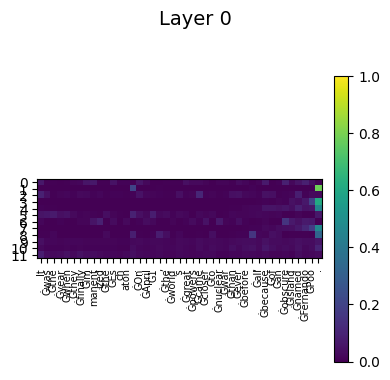

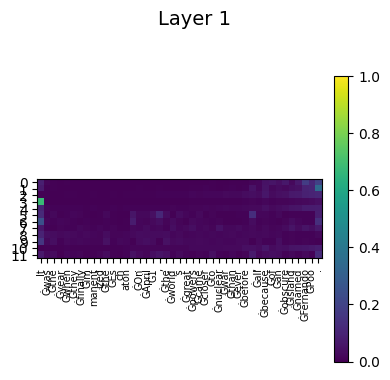

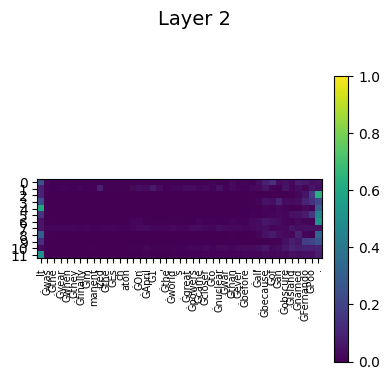

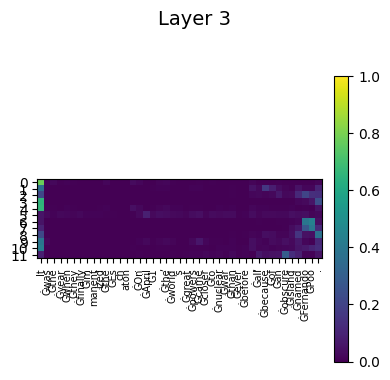

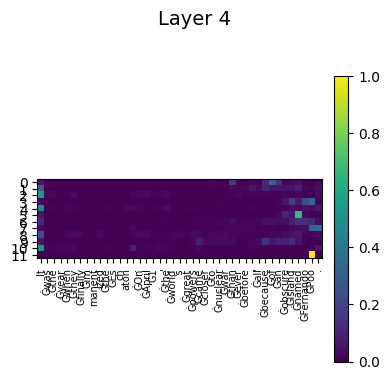

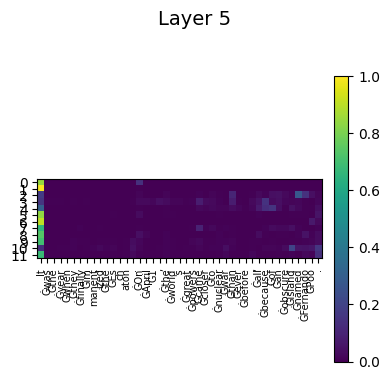

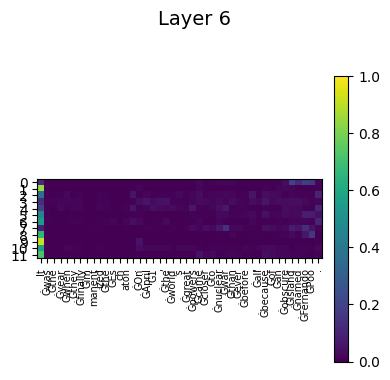

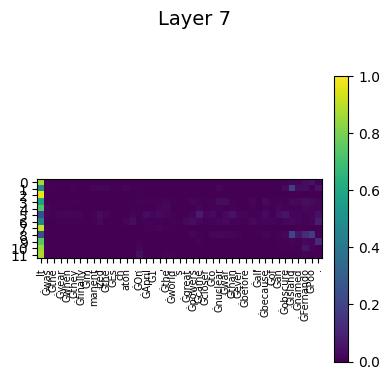

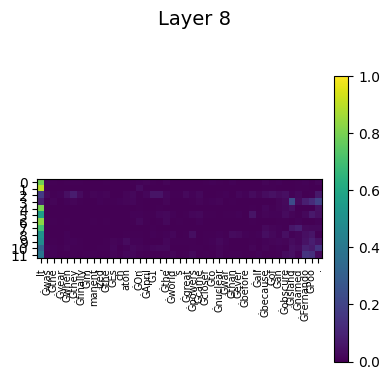

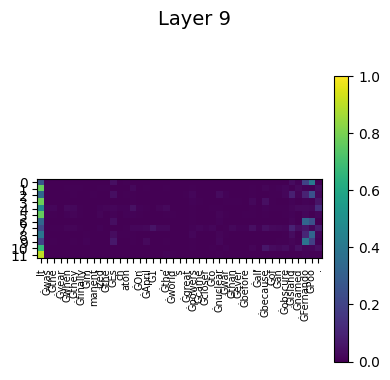

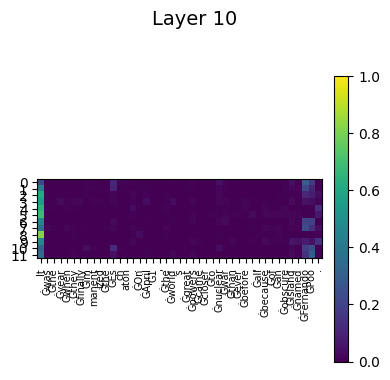

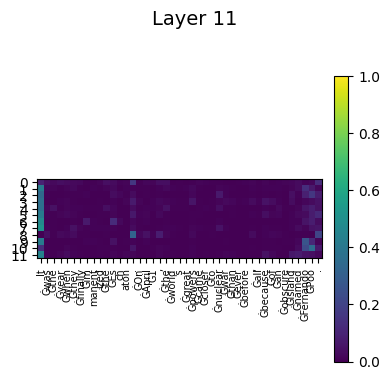

In [62]:
# but really, in this case, i only care about the final token's attention vector

# Decode tokens for axis labels
tokens = tokenizer.convert_ids_to_tokens(encoded_input["input_ids"][0])

num_layers = len(attentions)
num_heads = attentions[0].shape[1]

for layer_idx, layer_attn in enumerate(attentions):
    # layer_attn: (1, num_heads, seq_len, seq_len) -> drop batch dim
    attn = layer_attn[0].detach().numpy()

    cols = 1
    rows = 1
    fig, ax = plt.subplots(1, 1, figsize=(4 * cols, 4 * rows))
    fig.suptitle(f"Layer {layer_idx}", fontsize=14)

    final_attns = np.zeros((attn.shape[0],attn.shape[1]))

    for head_idx in range(num_heads):
        final_attns[head_idx] = attn[head_idx][-1]
        
    im = ax.imshow(final_attns, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(num_heads))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    #ax.set_yticklabels(tokens, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [76]:
# and of course there's no reason we couldn't just mean over all of this

mean_attn = np.mean(attn, axis=0)[-1]
mean_attn

array([0.33049086, 0.01432911, 0.01011932, 0.01034042, 0.01440193,
       0.01496998, 0.00689354, 0.01026881, 0.00507368, 0.00610881,
       0.01127405, 0.02705464, 0.00601846, 0.00683517, 0.06755212,
       0.00642709, 0.00975445, 0.00488881, 0.01921811, 0.01418597,
       0.00516996, 0.00275563, 0.00261704, 0.01390265, 0.00498084,
       0.00397316, 0.00344317, 0.01789724, 0.00735991, 0.00492786,
       0.00210645, 0.00324519, 0.01009034, 0.00332322, 0.01634763,
       0.01026155, 0.00873651, 0.0049693 , 0.01841321, 0.02312253,
       0.07799331, 0.08909664, 0.06906132], dtype=float32)

In [77]:
fake_attn = [float(i) for i in mean_attn]

In [78]:
print(output.last_hidden_state.shape)
vectors = output.last_hidden_state.detach().numpy()[0]
print(vectors.shape)

torch.Size([1, 43, 768])
(43, 768)


In [94]:
ms_complex = morse.MorseSmaleComplex(k=3, approximate=True)
result = ms_complex.fit_transform(vectors, mean_attn)


In [95]:
print("Partitions:", result.ascending_complex.compute_cells_at_lifetime(0))

Partitions: {22: [40, 41, 13, 27, 28, 33, 8, 3, 22, 7], 9: [39, 35, 9, 34], 26: [14, 29, 37, 6, 2, 36, 38, 5, 18, 32, 4, 24, 15, 10, 20, 23, 42, 26], 16: [16], 21: [19, 21, 1], 31: [31, 0, 25, 17], 12: [12, 11], 30: [30]}


In [96]:
print("Partitions:", result.descending_complex.compute_cells_at_lifetime(0))

Partitions: {42: [42, 16, 32, 18, 37, 15, 14], 5: [26, 5, 6, 23], 0: [0, 17, 25], 41: [12, 33, 41, 11, 13], 39: [39, 9, 4, 35], 40: [40, 7], 1: [20, 10, 29, 21, 19, 2, 24, 1], 38: [36, 38], 27: [28, 27, 30, 8, 3, 22], 34: [34, 31]}


In [97]:
for key in result.descending_complex.compute_cells_at_lifetime(0):
    print(tokens[key])

.
Ġthey
It
ĠPoo
Ġnamed
ĠFernando
Ġwas
Ġisland
Ġnuclear
Ġbecause


In [98]:
result.descending_complex.complex.lifetimes

{42: 0.06413345783948898,
 9: 0.0,
 19: 0.0,
 26: 0.0,
 21: 0.0,
 33: 0.0,
 4: 0.0,
 14: 0.0,
 6: 0.0,
 5: 0.011526809772476554,
 12: 0.0,
 0: inf,
 41: 0.0851234719157219,
 20: 0.0,
 39: 0.016287360806018114,
 3: 0.0,
 30: 0.0,
 25: 0.0,
 10: 0.0,
 40: 0.07115813763812184,
 31: 0.0,
 8: 0.0,
 29: 0.0,
 11: 0.0,
 32: 0.0,
 22: 0.0,
 35: 0.0,
 23: 0.0,
 13: 0.0,
 18: 0.0,
 37: 0.0,
 24: 0.0,
 28: 0.0,
 17: 0.0,
 2: 0.0,
 7: 0.0,
 1: 0.0030550621449947357,
 16: 0.0,
 38: 0.009676698595285416,
 27: 0.007556824944913387,
 34: 0.006086076609790325,
 36: 0.0,
 15: 0.0}

In [71]:
tokens

['It',
 'Ġwas',
 'Ġthe',
 'Ġyear',
 'Ġwhen',
 'Ġthey',
 'Ġfinally',
 'Ġim',
 'manent',
 'ized',
 'Ġthe',
 'ĠEs',
 'ch',
 'aton',
 '.',
 'ĠOn',
 'ĠApril',
 'Ġ1',
 ',',
 'Ġthe',
 'Ġworld',
 "'s",
 'Ġgreat',
 'Ġpowers',
 'Ġcame',
 'Ġcloser',
 'Ġto',
 'Ġnuclear',
 'Ġwar',
 'Ġthan',
 'Ġever',
 'Ġbefore',
 ',',
 'Ġall',
 'Ġbecause',
 'Ġof',
 'Ġan',
 'Ġobscure',
 'Ġisland',
 'Ġnamed',
 'ĠFernando',
 'ĠPoo',
 '.']

In [73]:
attn.shape

(12, 43, 43)

In [86]:
output.hidden_states[0].size()

torch.Size([1, 43, 768])

In [115]:
# so at every layer, we can ask what the average attention was across all heads
all_vectors = []
attentions = []
token_indices = []
layer_indices = []
for l, (layer, layer_attn) in enumerate(zip(output.hidden_states, attn)):

    summed_attn = layer_attn.sum(axis=0)
    for i, (token, token_attn) in enumerate(zip(layer[0].detach(), summed_attn)):
        all_vectors.append(token)
        attentions.append(token_attn)
        token_indices.append(i)
        layer_indices.append(l)

In [92]:
all_vectors[0].shape

torch.Size([768])

In [100]:
attentions[0]

np.float32(9.558772)

In [105]:
ms_complex = morse.MorseSmaleComplex(k=10, approximate=True)
result = ms_complex.fit_transform(all_vectors, attentions)

In [106]:
result.descending_complex.complex.lifetimes

{12: 0.0,
 351: 0.1353657841682434,
 89: 0.0,
 514: 0.0,
 424: 0.0,
 495: 0.0,
 51: 0.0,
 128: 0.0,
 2: 0.0,
 344: 0.0,
 365: 0.0,
 386: 0.0,
 276: 0.0,
 441: 0.0,
 423: 0.0,
 375: 0.0,
 20: 0.0,
 414: 0.0,
 370: 0.0,
 48: 0.0,
 258: 0.0,
 213: 0.0,
 434: 0.0,
 446: 0.0,
 146: 0.0,
 402: 0.0,
 372: 0.0,
 416: 0.0,
 41: 0.0,
 133: 0.0,
 306: 0.0,
 37: 0.0,
 18: 0.0,
 367: 0.9198701977729797,
 164: 0.0,
 83: 0.0,
 271: 0.0,
 280: 0.0,
 95: 0.0,
 44: 0.0,
 176: 0.0,
 373: 0.13369163870811462,
 311: 0.0,
 309: 0.0,
 350: 0.0,
 181: 0.0,
 451: 0.0,
 77: 0.0,
 206: 0.0,
 115: 0.0,
 477: 0.0,
 238: 0.0,
 231: 0.0,
 494: 0.0,
 407: 0.0,
 203: 0.0,
 466: 0.0,
 47: 0.0,
 50: 0.0,
 393: 0.0,
 101: 0.0,
 251: 0.0,
 489: 0.0,
 455: 0.0,
 443: 0.0,
 75: 0.0,
 334: 0.0,
 24: 0.0,
 134: 0.0,
 502: 0.0,
 479: 0.0,
 212: 0.0,
 113: 0.0,
 482: 0.0,
 511: 0.0,
 483: 0.0,
 28: 0.0,
 109: 0.0,
 4: 0.0,
 194: 0.0,
 322: 0.0,
 245: 0.0,
 504: 0.0,
 171: 0.0,
 496: 0.0,
 439: 0.0,
 42: 0.0,
 359: 0.90111860632

In [109]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(all_vectors)
embedding

array([[25.49298   ,  3.1983666 ],
       [25.387428  ,  3.218691  ],
       [25.392897  ,  3.248657  ],
       ...,
       [12.412107  , -0.6408722 ],
       [12.4468565 , -0.89872545],
       [ 9.511252  ,  3.8112965 ]], shape=(516, 2), dtype=float32)

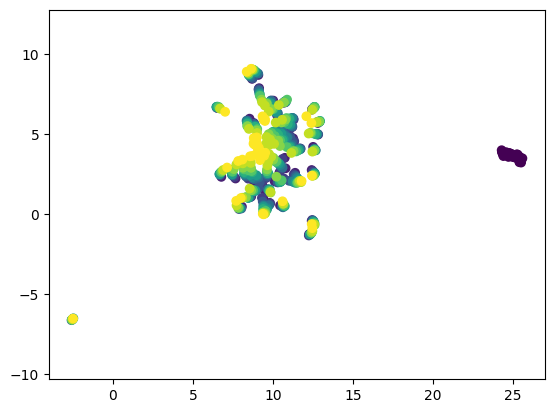

In [116]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=layer_indices
)
plt.gca().set_aspect('equal', 'datalim')

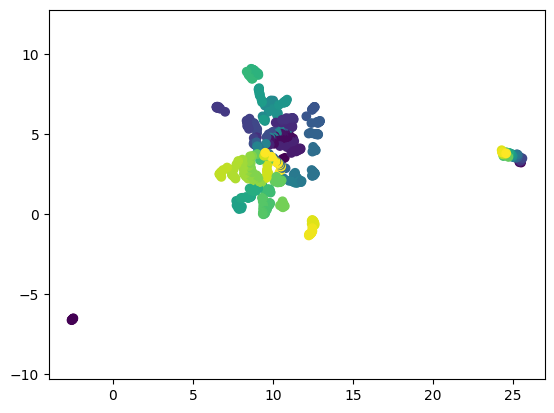

In [117]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=token_indices
)
plt.gca().set_aspect('equal', 'datalim')